# KEY CHANGE - MLP RATIO = 6

# 0. Import all core dependencies

In [1]:
# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision import models

import timm
from timm.models.swin_transformer import SwinTransformerBlock

# Optimisers and Schedulers
from torch.optim import AdamW, RMSprop, SGD
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR, StepLR

# Data Handling
from PIL import Image
import numpy as np
import pandas as pd
import cv2

# Data Visualisation - TODO
import matplotlib.pyplot as plt
import seaborn as sns

# Class Imbalance Handling - TODO
from imblearn.over_sampling import SMOTE
from collections import Counter

# Evaluation - TODO
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    recall_score
)

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from typing import Optional

# Utilities
from tqdm import tqdm
from einops import rearrange
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Locate source helper files
NOTEBOOK_DIR = os.getcwd()

SRC_PATH = os.path.abspath("../../src")

if SRC_PATH not in sys.path:
    sys.path.append(SRC_PATH)

from datasets import FERDataset
from torchvision.transforms import v2

# Reproducibility
import random
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Configure PyTorch to use my GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}")

C:\Users\aria_\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using cuda


# 1. Define all modules in Swin-Xception

## 1.1 Patch Embedding Block

In [2]:
class PatchEmbedding(nn.Module):
    def __init__(self,
                 in_channels:int=3,
                 dim:int=96,
                 patch_size:int=4):
        super(PatchEmbedding, self).__init__()

        self.patch_size = patch_size
        self.dim = dim

        self.patcher = nn.Conv2d(in_channels=in_channels, out_channels=dim, kernel_size=patch_size, stride=patch_size, padding=0)

        self.flatten = nn.Flatten(start_dim=2, end_dim=3)

        self.norm = nn.LayerNorm(dim)

    def forward(self, x):

        image_resolution = x.shape[-1]

        assert image_resolution % self.patch_size == 0, \
            f"Input image size must be divisible by patch size, \
            image shape: {image_resolution}, patch size: {self.patch_size}"
        
        x_patched = self.patcher(x)

        x_flattened = self.flatten(x_patched)

        x = x_flattened.permute(0,2,1)

        x = self.norm(x)

        return x

## 1.2 Patch Merging Block

In [3]:
class PatchMerging(nn.Module):
    def __init__(self, dim):
        super(PatchMerging, self).__init__()

        self.dim = dim

        self.reduction = nn.Linear(4*dim, 2*dim, bias=False)

        self.norm = nn.LayerNorm(4*dim)

    def forward(self, x):

        B, N, C = x.shape

        H = W = int(np.sqrt(N))

        assert H % 2 == 0 and W % 2 == 0, f"H and W must be even, got H={H}, W={W}"

        x = x.view(B, H, W, C)

        x0 = x[:, 0::2, 0::2, :]
        x1 = x[:, 1::2, 0::2, :]
        x2 = x[:, 0::2, 1::2, :]
        x3 = x[:, 1::2, 1::2, :]

        x = torch.cat([x0,x1,x2,x3], dim=-1)

        x = x.view(B, -1, 4*C)

        x = self.norm(x)

        x = self.reduction(x)

        return x

## 1.3 Depthwise Separable Convolution (The Xception side)

In [4]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self,
                 in_channels,
                 out_channels,
                 kernel_size:int=3):
        super(DepthwiseSeparableConv, self).__init__()

        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size, padding=kernel_size//2, groups=in_channels)
        
        self.gelu = nn.GELU()

        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):

        x = self.depthwise(x)

        x = self.gelu(x)

        x = self.pointwise(x)

        return x
    

## 1.4 Depthwise Separable FFN (Replaces MLP Head of Swin Block)

In [5]:
class DepthwiseSeparableFFN(nn.Module):
    def __init__(self,
                 dim,
                 mlp_ratio:int=6,
                 dropout:float=0.25):
        super(DepthwiseSeparableFFN, self).__init__()

        hidden_dim = int(dim * mlp_ratio)

        self.depthwise1 = DepthwiseSeparableConv(dim, hidden_dim, kernel_size=3)

        self.dropout1 = nn.Dropout(dropout)

        self.depthwise2 = DepthwiseSeparableConv(hidden_dim, dim, kernel_size=3)

        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):

        B, N, C = x.shape

        H = W = int(np.sqrt(N))

        x = x.transpose(1, 2).reshape(B, C, H, W)

        x = self.depthwise1(x)

        x = self.dropout1(x)

        x = self.depthwise2(x)

        x = self.dropout2(x)

        x = x.reshape(B, C, N).transpose(1, 2)

        return x

## 1.5 Swin-Xception Block

In [6]:
class SwinXceptionBlock(nn.Module):
    """Swin Transformer block that uses depthwise separable FFN instead of an MLP"""
    def __init__(self,
                 embedding_dim,
                 num_heads,
                 input_resolution,
                 window_size:int=7,
                 shift_size:int=0,
                 mlp_ratio:int=6):
        super(SwinXceptionBlock, self).__init__()

        from timm.models.swin_transformer import SwinTransformerBlock

        self.block = SwinTransformerBlock( # Use timm's Swin Transformer Block...
            dim=embedding_dim,
            input_resolution=input_resolution,
            num_heads=num_heads,
            window_size=window_size,
            shift_size=shift_size,
            mlp_ratio=mlp_ratio,
            proj_drop=0.1,
            drop_path=0.1
        )

        self.input_resolution = input_resolution

        self.block.mlp = DepthwiseSeparableFFN(embedding_dim, mlp_ratio) # But replace the mlp head with my DS-FFN

    def forward(self, x): # X input is sequential transformer data
        B, N, C = x.shape

        H, W = self.input_resolution # height and width

        x = x.view(B, H, W, C)

        # Swin blocks accept inputs as spatial grid
        x = self.block(x)

        # back to sequential data
        x = x.view(B, N, C)
        
        return x

## 1.6 Swin-Xception Backbone

In [7]:
class SwinXception(nn.Module):
    def __init__(self, num_classes:int=7, dropout:float=0.5):
        super(SwinXception, self).__init__()

        self.patch_embed = PatchEmbedding(in_channels=3, dim=96, patch_size=4)

        self.layer1 = nn.ModuleList([SwinXceptionBlock(96, num_heads=3, input_resolution=(56, 56), shift_size=0 if i % 2 == 0 else 3) for i in range(2)])
        self.merge1 = PatchMerging(96) # Reduce dimensions, increase channels

        self.layer2 = nn.ModuleList([SwinXceptionBlock(192, num_heads=6, input_resolution=(28, 28), shift_size=0 if i % 2 == 0 else 3) for i in range(2)])
        self.merge2 = PatchMerging(192)

        self.layer3 = nn.ModuleList([SwinXceptionBlock(384, num_heads=12, input_resolution=(14, 14), shift_size=0 if i % 2 == 0 else 3) for i in range(6)])
        self.merge3 = PatchMerging(384)

        self.layer4 = nn.ModuleList([SwinXceptionBlock(768, num_heads=24, input_resolution=(7, 7), shift_size=0 if i % 2 == 0 else 3) for i in range(2)])

        self.norm = nn.LayerNorm(768)
        
        self.avgpool1d = nn.AdaptiveAvgPool1d(output_size=1)

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(768, num_classes),
        )

    def forward(self, x):

        x = self.patch_embed(x)

        for block in self.layer1:
            x = block(x)
        x = self.merge1(x)

        for block in self.layer2:
            x = block(x)
        x = self.merge2(x)

        for block in self.layer3:
            x = block(x)
        x = self.merge3(x)

        for block in self.layer4:
            x = block(x)

        x = self.norm(x)
        x = x.transpose(1, 2)
        x = self.avgpool1d(x)
        x = torch.flatten(x, 1)
        x = self.head(x)

        return x

    def monte_carlo_dropout_predict(self, x, n_samples=10):
        self.train()
        predictions = []

        with torch.no_grad():
            for _ in range(n_samples):
                predictions.append(torch.softmax(self(x), dim=1))

        predictions = torch.stack(predictions)
        mean_pred = predictions.mean(dim=0)
        uncertainty = predictions.std(dim=0)

        return mean_pred, uncertainty

# 2. Image Preprocessing function

In [8]:
transform_train = v2.Compose([
    v2.RandomAffine(degrees=10, scale=(0.8, 1.0), translate=(0.1, 0.1), interpolation=v2.InterpolationMode.BILINEAR, fill=0),
    v2.Resize(size=(224, 224), antialias=True), 
    v2.RandomHorizontalFlip(p=0.5),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = v2.Compose([
    v2.Resize(size=(232, 232), interpolation=v2.InterpolationMode.BILINEAR, antialias=True),
    v2.CenterCrop(size=(224, 224)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_raf_train = FERDataset(os.path.abspath("../../datasets/RAFDB/DATASET/train"), transform_train)
raf_test = FERDataset(os.path.abspath("../../datasets/RAFDB/DATASET/test"), transform_test)
fer_test = FERDataset(os.path.abspath("../../datasets/FER2013/test"), transform_test)

train_size = int(0.8 * len(full_raf_train))
val_size = len(full_raf_train) - train_size

raf_train, raf_val = random_split(full_raf_train, [train_size, val_size])

train_loader = DataLoader(raf_train, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(raf_val, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_raf_loader = DataLoader(raf_test, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_fer_loader = DataLoader(fer_test, batch_size=32,shuffle=False, num_workers=4, pin_memory=True)

print(f"RAF-DB Training set images: {len(raf_train)}")
print(f"RAF-DB Validation set images: {len(raf_val)}")
print(f"RAF-DB Test set images: {len(raf_test)}")
print(f"FER2013 Test set images: {len(fer_test)}")

RAF-DB Training set images: 9816
RAF-DB Validation set images: 2455
RAF-DB Test set images: 3068
FER2013 Test set images: 7178


# 3. Stage 1: End-to-End Training

## 3.1 Train Functions

### 3.1.1 Baseline Train Function

In [9]:
def train_one_epoch(model, data_loader, criterion, optimiser, device):
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(data_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimiser.zero_grad()
        
        outputs = model(images)

        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()
        optimiser.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(data_loader)
    epoch_acc = correct * 100. / total
    return epoch_loss, epoch_acc

## 3.2 Validation Function

In [10]:
def validate(model, data_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(data_loader):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss = running_loss / len(data_loader)
    val_acc = correct * 100. / total
    
    return val_loss, val_acc

## 3.3 Training and Validation from source domain

### 3.3.1 Set up my model

In [20]:
PATH = "model_checkpoints/latest.pth"
os.makedirs("model_checkpoints", exist_ok=True)

epochs = 100

model = SwinXception(num_classes=7).to(device)
criterion = nn.CrossEntropyLoss()
optimiser = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimiser, T_max=epochs, eta_min=1e-6)

start_epoch = 0

if os.path.exists(PATH):
    checkpoint = torch.load(PATH, map_location=device)
    start_epoch = checkpoint["epoch"] + 1
    print(f"Checkpoint found! Starting from epoch {start_epoch}...")
    
    model.load_state_dict(checkpoint["model_state_dict"])
    optimiser.load_state_dict(checkpoint["optimiser_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
else:
    print("No model checkpoints found. Starting from epoch 1...")

No model checkpoints found. Starting from epoch 1...


In [21]:
if start_epoch == 0:
    # Freeze backbone, train only head (Epochs 1-3)
    # This aligns the random head with the pre-trained body without wrecking the body
    for param in model.parameters():
        param.requires_grad = False
    for param in model.head.parameters(): # ResNet's head is called 'fc'
        param.requires_grad = True
        
    print("Warming up head (3 Epochs)...")
    # Use Adam for quick head alignment
    warmup_optim = AdamW(model.head.parameters(), lr=3e-3)
    
    for epoch in range(3):
        model.train()
        for images, labels in tqdm(train_loader, desc=f"Warmup {epoch+1}"):
            images, labels = images.to(device), labels.to(device)
            warmup_optim.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            warmup_optim.step()

    # Unfreeze and Train All (Epochs 4-30)
    print("Fine-tuning entire model...")
    for param in model.parameters():
        param.requires_grad = True

for epoch in range(start_epoch, epochs):
    print("="*60)
    print(f"Epoch {epoch+1}/{epochs}")
    
    print("Training on RAF-DB...")
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimiser, device)

    print("Validating on RAF-DB...")
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    scheduler.step()

    print(f"RAF-DB Training    | Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%")
    print(f"RAF-DB Validation  | Loss: {val_loss:.4f} | Accuracy: {val_acc:.2f}%")

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimiser_state_dict": optimiser.state_dict(),
        "scheduler_state_dict": scheduler.state_dict()
    }

    torch.save(checkpoint, PATH)
    
print("="*60)
torch.save(model.state_dict(), 'swin_xception_baseline.pth')

Warming up head (3 Epochs)...


Warmup 3: 100%|██████████████████████████████████████████████████████████████████████| 307/307 [00:40<00:00,  7.63it/s]


Fine-tuning entire model...
Epoch 1/100
Training on RAF-DB...


100%|████████████████████████████████████████████████████████████████████████████████| 307/307 [01:33<00:00,  3.28it/s]


Validating on RAF-DB...


...

Validating on RAF-DB...


100%|██████████████████████████████████████████████████████████████████████████████████| 77/77 [00:15<00:00,  5.11it/s]


RAF-DB Training    | Loss: 0.3159 | Accuracy: 88.48%
RAF-DB Validation  | Loss: 0.7162 | Accuracy: 78.62%
Epoch 90/100
Training on RAF-DB...


  0%|                                                                                          | 0/307 [00:02<?, ?it/s]


KeyboardInterrupt: 

In [23]:
criterion = nn.CrossEntropyLoss()

print("Testing on RAF-DB...")
raf_loss, raf_acc = validate(model, test_raf_loader, criterion, device)

print("Testing of FER2013...")
fer_loss, fer_acc = validate(model, test_fer_loader, criterion, device)

print(f"RAF-DB Testing  | Loss: {raf_loss:.4f} | Accuracy: {raf_acc:.2f}%")
print(f"FER2013 Testing | Loss: {fer_loss:.4f} | Accuracy: {fer_acc:.2f}%")

Testing on RAF-DB...


100%|██████████████████████████████████████████████████████████████████████████████████| 96/96 [00:16<00:00,  5.83it/s]


Testing of FER2013...


100%|████████████████████████████████████████████████████████████████████████████████| 225/225 [00:29<00:00,  7.56it/s]

RAF-DB Testing  | Loss: 0.6539 | Accuracy: 81.13%
FER2013 Testing | Loss: 2.5735 | Accuracy: 46.41%


Save an interrupted model:

In [22]:
torch.save(model.state_dict(), 'swin_xception_baseline.pth')

Load a baseline model:

In [11]:
model = SwinXception(num_classes=7).to(device)

swin_xception_baseline = torch.load('swin_xception_baseline.pth', map_location=device)

model.load_state_dict(swin_xception_baseline)
print(f"Base SwinXception model loaded!")

Base SwinXception model loaded!


# 4. Evaluation and Metrics, Initial training

## 4.1 Confusion matrix

### 4.1.1 Run one evaluation to get all predictions

In [12]:
def get_predictions(model, dataloader, device):
    """Get all predictions and true labels"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Getting predictions"):
            images = images.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    return np.array(all_preds), np.array(all_labels)

### 4.1.2 Plotting the confusion matrices

In [13]:
def plot_confusion_matrix(y_true, y_pred, class_names, title, save_path=None):
    """Plot and optionally save confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    
    # Normalize to percentages
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, ax=ax1)
    ax1.set_title(f'{title} - Raw Counts')
    ax1.set_ylabel('True Label')
    ax1.set_xlabel('Predicted Label')
    
    # Percentages
    sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax2)
    ax2.set_title(f'{title} - Percentages (%)')
    ax2.set_ylabel('True Label')
    ax2.set_xlabel('Predicted Label')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved confusion matrix to {save_path}")
    
    plt.show()

### 4.1.3 Detailed metrics

In [14]:
def print_detailed_metrics(y_true, y_pred, class_names, dataset_name):
    """Print detailed classification metrics"""
    print(f"\n{'='*60}")
    print(f"{dataset_name} - Detailed Metrics")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    
    # Per-class accuracy
    cm = confusion_matrix(y_true, y_pred)
    per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100
    
    print("\nPer-Class Accuracy:")
    for i, (class_name, acc) in enumerate(zip(class_names, per_class_acc)):
        print(f"{class_name:12s}: {acc:6.2f}%")
    
    # Overall accuracy
    overall_acc = (y_true == y_pred).sum() / len(y_true) * 100
    print(f"\nOverall Accuracy: {overall_acc:.2f}%")

### 4.1.4 Generate Matrices


Generating Confusion Matrices and Metrics

Evaluating RAF-DB test set...


Getting predictions: 100%|█████████████████████████████████████████████████████████████| 96/96 [00:17<00:00,  5.59it/s]


Saved confusion matrix to rafdb_confusion_matrix.png


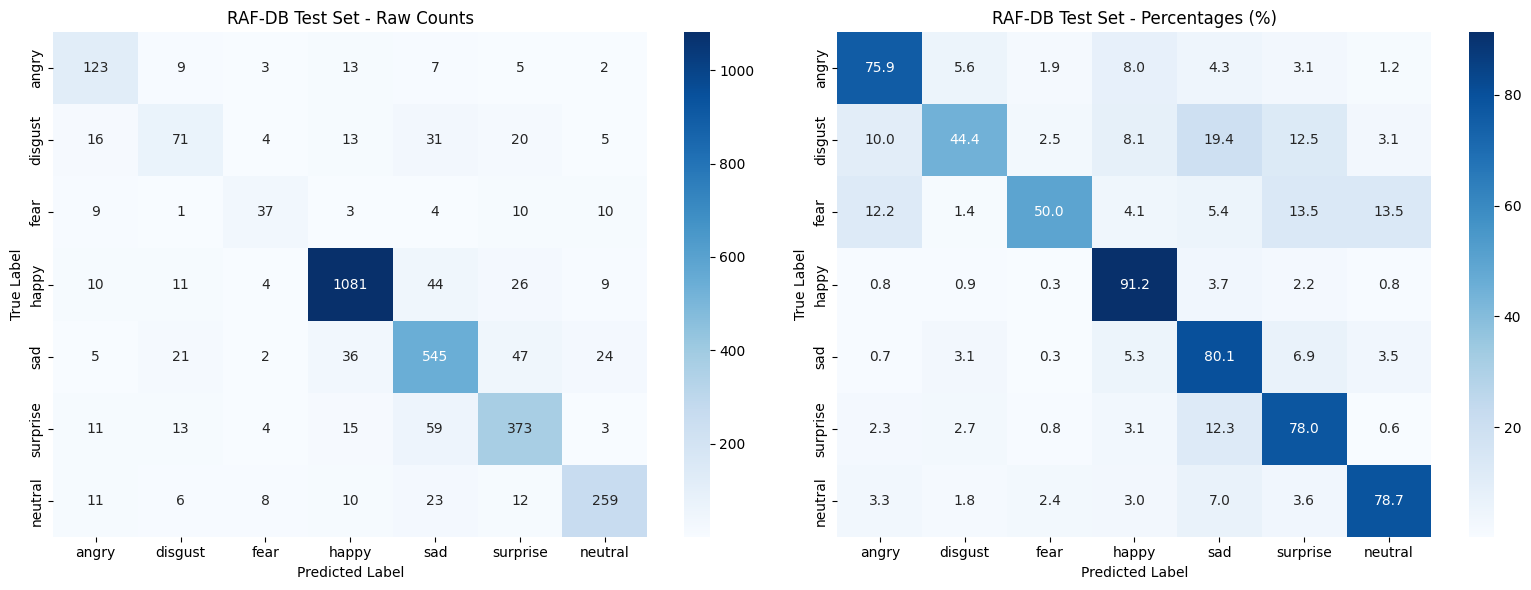


RAF-DB - Detailed Metrics
              precision    recall  f1-score   support

       angry     0.6649    0.7593    0.7089       162
     disgust     0.5379    0.4437    0.4863       160
        fear     0.5968    0.5000    0.5441        74
       happy     0.9231    0.9122    0.9177      1185
         sad     0.7644    0.8015    0.7825       680
    surprise     0.7566    0.7803    0.7683       478
     neutral     0.8301    0.7872    0.8081       329

    accuracy                         0.8113      3068
   macro avg     0.7248    0.7120    0.7166      3068
weighted avg     0.8104    0.8113    0.8101      3068


Per-Class Accuracy:
angry       :  75.93%
disgust     :  44.38%
fear        :  50.00%
happy       :  91.22%
sad         :  80.15%
surprise    :  78.03%
neutral     :  78.72%

Overall Accuracy: 81.13%

Evaluating FER2013 test set...


Getting predictions: 100%|███████████████████████████████████████████████████████████| 225/225 [00:29<00:00,  7.69it/s]


Saved confusion matrix to fer2013_confusion_matrix.png


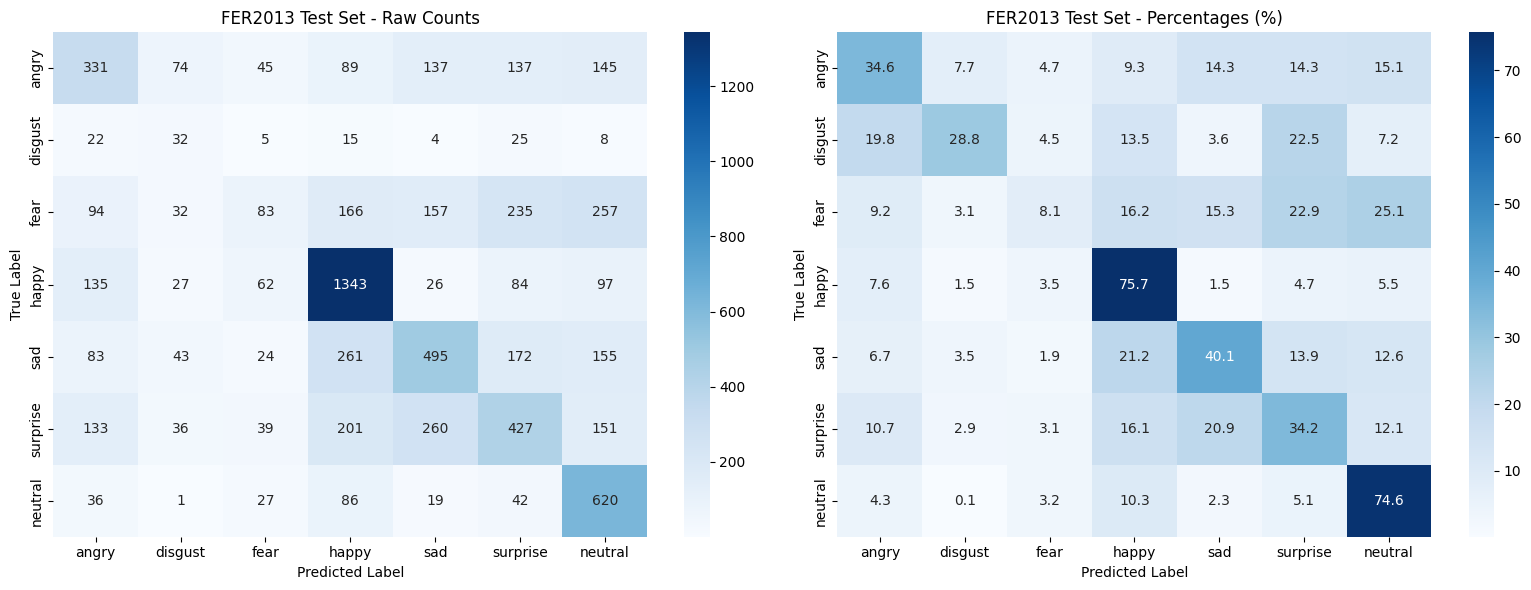


FER2013 - Detailed Metrics
              precision    recall  f1-score   support

       angry     0.3969    0.3455    0.3694       958
     disgust     0.1306    0.2883    0.1798       111
        fear     0.2912    0.0811    0.1268      1024
       happy     0.6215    0.7570    0.6826      1774
         sad     0.4508    0.4015    0.4247      1233
    surprise     0.3806    0.3424    0.3605      1247
     neutral     0.4327    0.7461    0.5477       831

    accuracy                         0.4641      7178
   macro avg     0.3863    0.4231    0.3845      7178
weighted avg     0.4438    0.4641    0.4379      7178


Per-Class Accuracy:
angry       :  34.55%
disgust     :  28.83%
fear        :   8.11%
happy       :  75.70%
sad         :  40.15%
surprise    :  34.24%
neutral     :  74.61%

Overall Accuracy: 46.41%


In [27]:
# Emotion labels
emotions = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

print("\n" + "="*60)
print("Generating Confusion Matrices and Metrics")
print("="*60)

# RAF-DB Test Set
print("\nEvaluating RAF-DB test set...")
raf_preds, raf_labels = get_predictions(model, test_raf_loader, device)
plot_confusion_matrix(raf_labels, raf_preds, emotions, 
                     'RAF-DB Test Set',
                     save_path='rafdb_confusion_matrix.png')
print_detailed_metrics(raf_labels, raf_preds, emotions, 'RAF-DB')

# FER2013 Test Set
print("\nEvaluating FER2013 test set...")
fer_preds, fer_labels = get_predictions(model, test_fer_loader, device)
plot_confusion_matrix(fer_labels, fer_preds, emotions, 
                     'FER2013 Test Set', 
                     save_path='fer2013_confusion_matrix.png')
print_detailed_metrics(fer_labels, fer_preds, emotions, 'FER2013')

### 4.1.5 Compare Minority class performance

In [28]:
print("\n" + "="*60)
print("Minority Class Performance (Disgust & Fear)")
print("="*60)

minority_classes = ['disgust', 'fear']
minority_indices = [emotions.index(cls) for cls in minority_classes]

for cls_name, cls_idx in zip(minority_classes, minority_indices):
    fer_mask = fer_labels == cls_idx
    raf_mask = raf_labels == cls_idx
    
    if fer_mask.sum() > 0:
        fer_acc = (fer_preds[fer_mask] == fer_labels[fer_mask]).sum() / fer_mask.sum() * 100
        print(f"{cls_name.capitalize()} - FER2013: {fer_acc:.2f}% ({fer_mask.sum()} samples)")
    
    if raf_mask.sum() > 0:
        raf_acc = (raf_preds[raf_mask] == raf_labels[raf_mask]).sum() / raf_mask.sum() * 100
        print(f"{cls_name.capitalize()} - RAF-DB:  {raf_acc:.2f}% ({raf_mask.sum()} samples)")
    print()


Minority Class Performance (Disgust & Fear)
Disgust - FER2013: 28.83% (111 samples)
Disgust - RAF-DB:  44.38% (160 samples)

Fear - FER2013: 8.11% (1024 samples)
Fear - RAF-DB:  50.00% (74 samples)



## 4.2 UAR and WAR

### 4.2.1 UAR and WAR calculation

In [29]:
def calculate_uar_war(y_true, y_pred, class_names):
    """
    Calculate UAR and WAR metrics
    
    UAR (Unweighted Average Recall): Mean of per-class recalls (treats all classes equally)
    WAR (Weighted Average Recall): Weighted mean of per-class recalls (weighted by class frequency)
    """
    cm = confusion_matrix(y_true, y_pred)
    
    # Per-class recall (same as per-class accuracy for single-label classification)
    per_class_recall = cm.diagonal() / cm.sum(axis=1)
    
    # UAR: Simple average of all class recalls
    uar = np.mean(per_class_recall) * 100
    
    # WAR: Weighted average by class support
    class_support = cm.sum(axis=1)
    war = np.average(per_class_recall, weights=class_support) * 100
    
    return uar, war, per_class_recall

### 4.2.2 Detailed metrics with UAR and WAR

In [30]:
def print_detailed_metrics_with_uar_war(y_true, y_pred, class_names, dataset_name):
    """Print detailed classification metrics including UAR and WAR"""
    print(f"\n{'='*60}")
    print(f"{dataset_name} - Detailed Metrics")
    print(f"{'='*60}")
    
    # Standard classification report
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    
    # Calculate UAR and WAR
    uar, war, per_class_recall = calculate_uar_war(y_true, y_pred, class_names)
    
    print("\n" + "-"*60)
    print("Per-Class Recall (%):")
    print("-"*60)
    for class_name, recall in zip(class_names, per_class_recall):
        print(f"{class_name:12s}: {recall*100:6.2f}%")
    
    print("\n" + "-"*60)
    print("Summary Metrics:")
    print("-"*60)
    overall_acc = (y_true == y_pred).sum() / len(y_true) * 100
    print(f"Overall Accuracy: {overall_acc:.2f}%")
    print(f"WAR (Weighted Average Recall): {war:.2f}%")
    print(f"UAR (Unweighted Average Recall): {uar:.2f}%")
    print("-"*60)

### 4.2.3 Generate confusion matrices for test sets with UAR and WAR


Generating Confusion Matrices and Metrics

Evaluating RAF-DB test set...


Getting predictions: 100%|█████████████████████████████████████████████████████████████| 96/96 [00:16<00:00,  5.85it/s]


Saved confusion matrix to rafdb_confusion_matrix.png


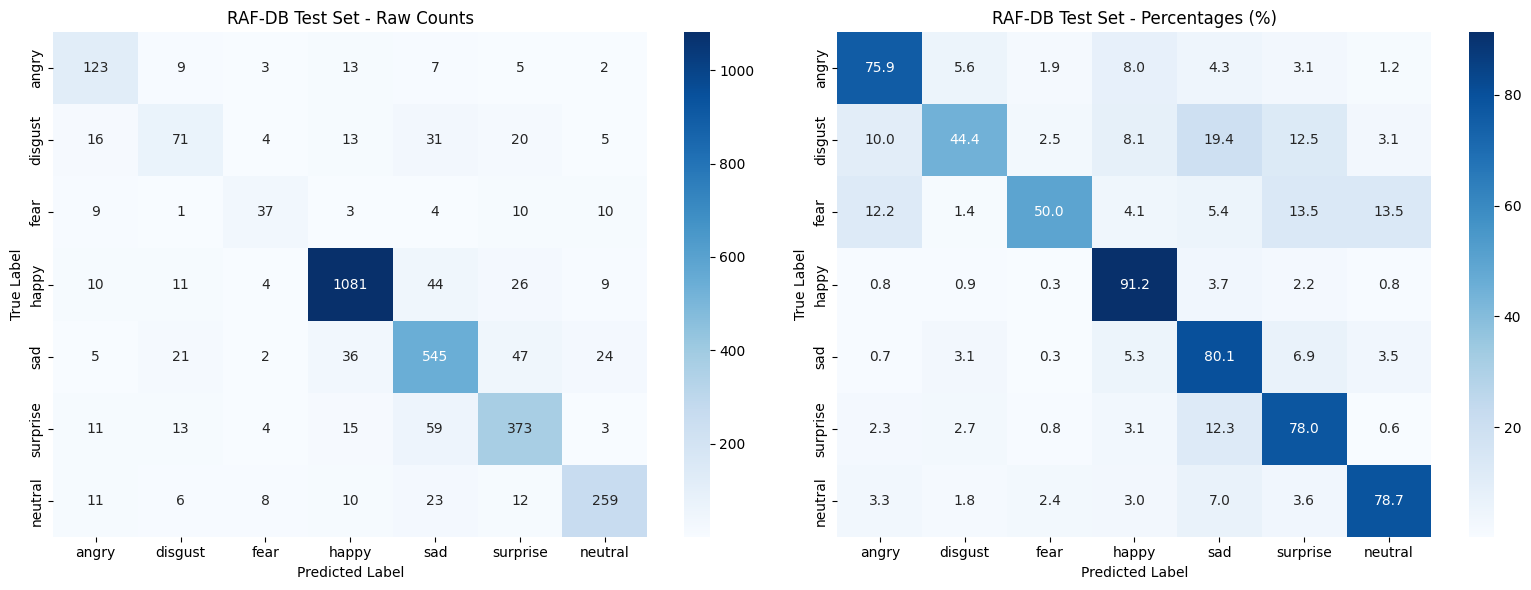


RAF-DB - Detailed Metrics
              precision    recall  f1-score   support

       angry     0.6649    0.7593    0.7089       162
     disgust     0.5379    0.4437    0.4863       160
        fear     0.5968    0.5000    0.5441        74
       happy     0.9231    0.9122    0.9177      1185
         sad     0.7644    0.8015    0.7825       680
    surprise     0.7566    0.7803    0.7683       478
     neutral     0.8301    0.7872    0.8081       329

    accuracy                         0.8113      3068
   macro avg     0.7248    0.7120    0.7166      3068
weighted avg     0.8104    0.8113    0.8101      3068


------------------------------------------------------------
Per-Class Recall (%):
------------------------------------------------------------
angry       :  75.93%
disgust     :  44.38%
fear        :  50.00%
happy       :  91.22%
sad         :  80.15%
surprise    :  78.03%
neutral     :  78.72%

------------------------------------------------------------
Summary Metrics

Getting predictions: 100%|███████████████████████████████████████████████████████████| 225/225 [00:29<00:00,  7.68it/s]


Saved confusion matrix to fer2013_confusion_matrix.png


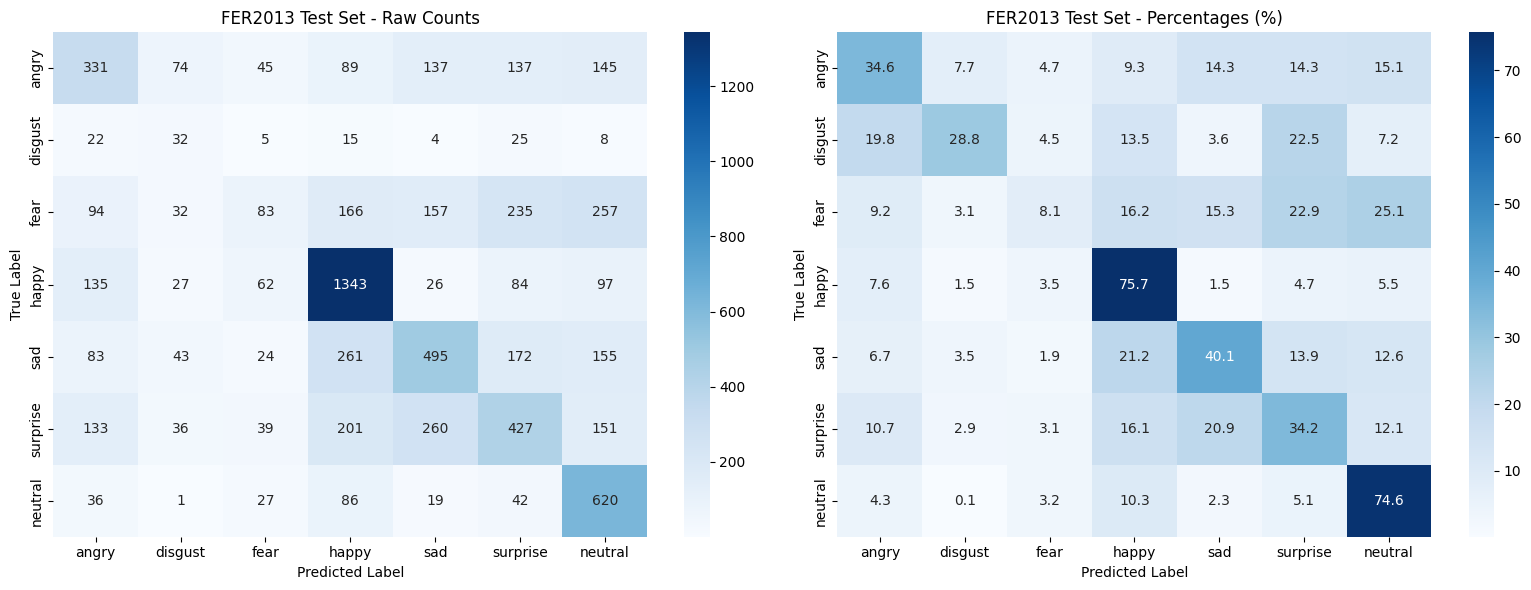


FER2013 - Detailed Metrics
              precision    recall  f1-score   support

       angry     0.3969    0.3455    0.3694       958
     disgust     0.1306    0.2883    0.1798       111
        fear     0.2912    0.0811    0.1268      1024
       happy     0.6215    0.7570    0.6826      1774
         sad     0.4508    0.4015    0.4247      1233
    surprise     0.3806    0.3424    0.3605      1247
     neutral     0.4327    0.7461    0.5477       831

    accuracy                         0.4641      7178
   macro avg     0.3863    0.4231    0.3845      7178
weighted avg     0.4438    0.4641    0.4379      7178


------------------------------------------------------------
Per-Class Recall (%):
------------------------------------------------------------
angry       :  34.55%
disgust     :  28.83%
fear        :   8.11%
happy       :  75.70%
sad         :  40.15%
surprise    :  34.24%
neutral     :  74.61%

------------------------------------------------------------
Summary Metric

In [31]:
print("\n" + "="*60)
print("Generating Confusion Matrices and Metrics")
print("="*60)

# RAF-DB Test Set
print("\nEvaluating RAF-DB test set...")
raf_preds, raf_labels = get_predictions(model, test_raf_loader, device)
plot_confusion_matrix(raf_labels, raf_preds, emotions, 
                     'RAF-DB Test Set',
                     save_path='rafdb_confusion_matrix.png')
print_detailed_metrics_with_uar_war(raf_labels, raf_preds, emotions, 'RAF-DB')

# FER2013 Test Set
print("\nEvaluating FER2013 test set...")
fer_preds, fer_labels = get_predictions(model, test_fer_loader, device)
plot_confusion_matrix(fer_labels, fer_preds, emotions, 
                     'FER2013 Test Set', 
                     save_path='fer2013_confusion_matrix.png')
print_detailed_metrics_with_uar_war(fer_labels, fer_preds, emotions, 'FER2013')

### 4.2.4 Summary Comparison Table

In [32]:
print("\n" + "="*60)
print("Cross-Dataset Performance Summary")
print("="*60)

raf_uar, raf_war, _ = calculate_uar_war(raf_labels, raf_preds, emotions)
fer_uar, fer_war, _ = calculate_uar_war(fer_labels, fer_preds, emotions)

raf_acc = (raf_preds == raf_labels).sum() / len(raf_labels) * 100
fer_acc = (fer_preds == fer_labels).sum() / len(fer_labels) * 100

print(f"\n{'Metric':<30} {'FER2013':>12} {'RAF-DB':>12}")
print("-"*60)
print(f"{'Overall Accuracy':<30} {raf_acc:>11.2f}% {fer_acc:>11.2f}%")
print(f"{'WAR (Weighted Avg Recall)':<30} {raf_war:>11.2f}% {fer_war:>11.2f}%")
print(f"{'UAR (Unweighted Avg Recall)':<30} {raf_uar:>11.2f}% {fer_uar:>11.2f}%")
print("-"*60)


Cross-Dataset Performance Summary

Metric                              FER2013       RAF-DB
------------------------------------------------------------
Overall Accuracy                     81.13%       46.41%
WAR (Weighted Avg Recall)            81.13%       46.41%
UAR (Unweighted Avg Recall)          71.20%       42.31%
------------------------------------------------------------


### 4.2.5 Minority Class Performance with UAR and WAR

In [33]:
print("\n" + "="*60)
print("Minority Class Performance (Disgust & Fear)")
print("="*60)

minority_classes = ['disgust', 'fear']
minority_indices = [emotions.index(cls) for cls in minority_classes]

print(f"\n{'Class':<12} {'Dataset':<10} {'Recall':<10} {'Samples':<10}")
print("-"*60)

for cls_name, cls_idx in zip(minority_classes, minority_indices):
    
    # RAF-DB
    raf_mask = raf_labels == cls_idx
    if raf_mask.sum() > 0:
        raf_recall = (raf_preds[raf_mask] == raf_labels[raf_mask]).sum() / raf_mask.sum() * 100
        print(f"{cls_name.capitalize():<12} {'RAF-DB':<10} {raf_recall:>8.2f}% {raf_mask.sum():>9}")

    # FER2013
    fer_mask = fer_labels == cls_idx
    if fer_mask.sum() > 0:
        fer_recall = (fer_preds[fer_mask] == fer_labels[fer_mask]).sum() / fer_mask.sum() * 100
        print(f"{cls_name.capitalize():<12} {'FER2013':<10} {fer_recall:>8.2f}% {fer_mask.sum():>9}")
    
    print()


Minority Class Performance (Disgust & Fear)

Class        Dataset    Recall     Samples   
------------------------------------------------------------
Disgust      RAF-DB        44.38%       160
Disgust      FER2013       28.83%       111

Fear         RAF-DB        50.00%        74
Fear         FER2013        8.11%      1024



# 5. Stage 2: Feature Extraction and Synthesis

## 5.1 Extract Features

In [34]:
def extract_features(model, dataloader, device):
    model.eval()
    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Extracting Features"):
            images = images.to(device)

            x = model.patch_embed(images)

            for block in model.layer1:
                x = block(x)
            x = model.merge1(x)

            for block in model.layer2:
                x = block(x)
            x = model.merge2(x)

            for block in model.layer3:
                x = block(x)
            x = model.merge3(x)
            
            for block in model.layer4:
                x = block(x)

            x = model.norm(x)
            x = x.transpose(1, 2)
            x = model.avgpool1d(x)
            x = torch.flatten(x, 1)

            all_features.append(x.cpu().numpy())
            all_labels.append(labels.numpy())

        features = np.vstack(all_features)
        labels = np.concatenate(all_labels)

        return features, labels

## 5.2 Apply SMOTE on extracted deep features

In [35]:
def apply_smote(features, labels, random_state=42):
    print("Original class distribution:")
    print(Counter(labels))
    
    smote = SMOTE(random_state=random_state, k_neighbors=5)
    balanced_features, balanced_labels = smote.fit_resample(features, labels)

    print("Balanced class distribution:")
    print(Counter(balanced_labels))

    return balanced_features, balanced_labels

In [36]:
features, labels = extract_features(model, train_loader, device)
balanced_features, balanced_labels = apply_smote(features, labels)

Extracting Features: 100%|███████████████████████████████████████████████████████████| 307/307 [00:37<00:00,  8.14it/s]


Original class distribution:
Counter({np.int64(3): 3791, np.int64(4): 2042, np.int64(5): 1591, np.int64(6): 1042, np.int64(1): 572, np.int64(0): 552, np.int64(2): 226})
Balanced class distribution:
Counter({np.int64(4): 3791, np.int64(5): 3791, np.int64(3): 3791, np.int64(6): 3791, np.int64(0): 3791, np.int64(1): 3791, np.int64(2): 3791})


# 6. Stage 3: Retraining the MLP Head

In [37]:
def retrain_mlp_head(model, features, labels, device, epochs=20, batch_size=128, lr=1e-3, weight_decay=1e-3):
    # Freeze all params in Swin-X backbone
    for param in model.patch_embed.parameters():
        param.requires_grad = False
    for stage in [model.layer1, model.layer2, model.layer3, model.layer4]:
        for block in stage:
            for param in block.parameters():
                param.requires_grad = False

    for merge in [model.merge1, model.merge2, model.merge3]:
        for param in merge.parameters():
            param.requires_grad = False

    for param in model.head.parameters():
        param.requires_grad = True

    features_tensor = torch.FloatTensor(features)
    labels_tensor = torch.LongTensor(labels)
    dataset = torch.utils.data.TensorDataset(features_tensor, labels_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    criterion = nn.CrossEntropyLoss()
    optimiser = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    model.train()

    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_features, batch_labels in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)

            optimiser.zero_grad()

            outputs = model.head(batch_features)

            loss = criterion(outputs, batch_labels)

            loss.backward()
            optimiser.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += batch_labels.size(0)
            correct += predicted.eq(batch_labels).sum().item()

        epoch_loss = running_loss / len(dataloader)
        epoch_acc = correct * 100. / total

        print(f"Epoch {epoch+1}/{epochs}   Loss: {epoch_loss}   Accuracy: {epoch_acc}")

    return model

In [38]:
model = retrain_mlp_head(model, balanced_features, balanced_labels, device)

torch.save(model.state_dict(), 'swin_xception_final.pth')

Epoch 1/20: 100%|███████████████████████████████████████████████████████████████████| 208/208 [00:00<00:00, 256.64it/s]


Epoch 1/20   Loss: 0.24184250330122617   Accuracy: 91.49866224516713


Epoch 2/20: 100%|███████████████████████████████████████████████████████████████████| 208/208 [00:00<00:00, 282.70it/s]


Epoch 2/20   Loss: 0.23567536953263557   Accuracy: 91.57402871462486


Epoch 3/20: 100%|███████████████████████████████████████████████████████████████████| 208/208 [00:00<00:00, 240.47it/s]


...

Epoch 18/20   Loss: 0.2328413137091467   Accuracy: 91.73229830048611


Epoch 19/20: 100%|██████████████████████████████████████████████████████████████████| 208/208 [00:00<00:00, 211.59it/s]


Epoch 19/20   Loss: 0.23196026131224173   Accuracy: 91.81143309341674


Epoch 20/20: 100%|██████████████████████████████████████████████████████████████████| 208/208 [00:01<00:00, 190.19it/s]


Epoch 20/20   Loss: 0.23184051289438054   Accuracy: 91.68707841881147


In [18]:
model = SwinXception(num_classes=7).to(device)

swin_xception_final = torch.load('swin_xception_final.pth', map_location=device)

model.load_state_dict(swin_xception_final)
print(f"Post-SMOTE SwinXception model loaded!")

Post-SMOTE SwinXception model loaded!


In [19]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {total_params}")

Number of parameters: 36468865


# 7. Evaluation Metrics and Visualisation on Balanced set

## 7.1 Validate Loss and Accuracy on Test sets

In [12]:
raf_loss, raf_acc = validate(model, test_raf_loader, nn.CrossEntropyLoss(), device)
fer_loss, fer_acc = validate(model, test_fer_loader, nn.CrossEntropyLoss(), device)

print(f"RAF-DB | new loss: {raf_loss:.4f} | new accuracy: {raf_acc:.2f}")
print(f"FER2013 | new loss: {fer_loss:.4f} | new accuracy: {fer_acc:.2f}")

100%|████████████████████████████████████████████████████████████████████████████████| 225/225 [00:35<00:00,  6.39it/s]

RAF-DB | new loss: 0.8557 | new accuracy: 79.24
FER2013 | new loss: 3.2461 | new accuracy: 45.01



Generating Confusion Matrices and Metrics

Evaluating RAF-DB test set...


Getting predictions: 100%|█████████████████████████████████████████████████████████████| 96/96 [00:17<00:00,  5.62it/s]


Saved confusion matrix to rafdb_confusion_matrix_final.png


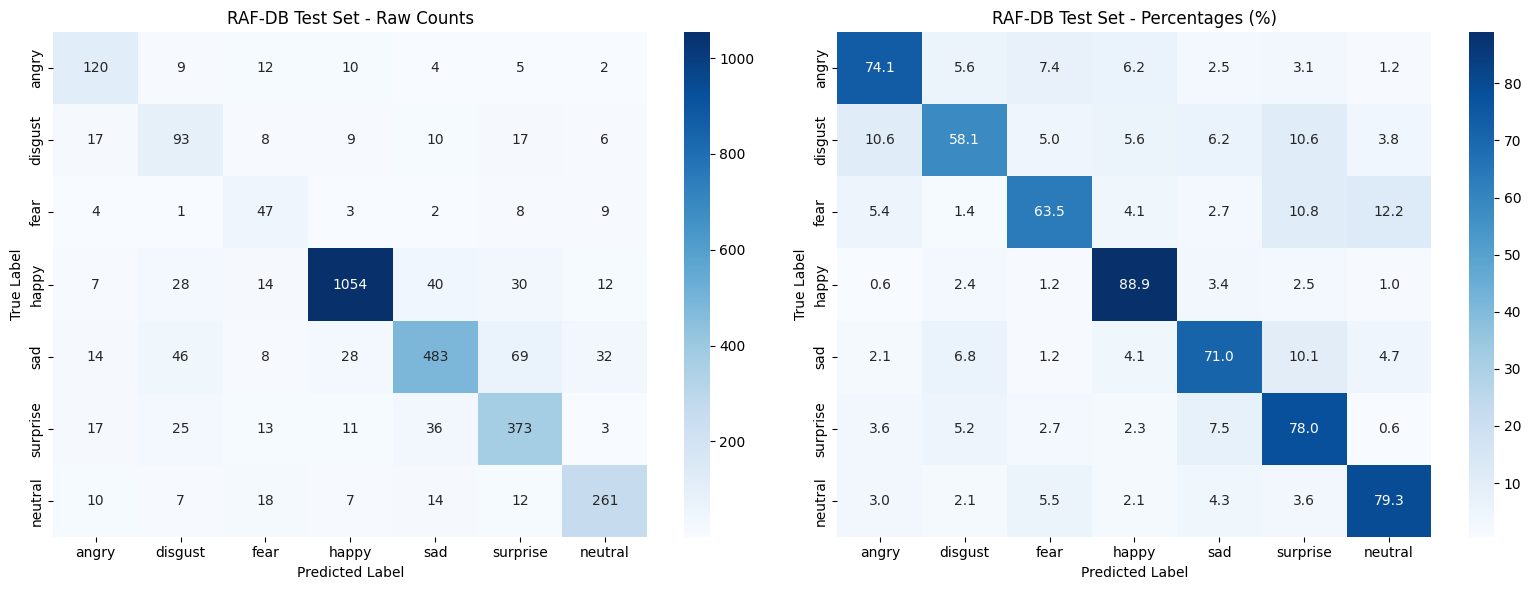


RAF-DB - Detailed Metrics
              precision    recall  f1-score   support

       angry     0.6349    0.7407    0.6838       162
     disgust     0.4450    0.5813    0.5041       160
        fear     0.3917    0.6351    0.4845        74
       happy     0.9394    0.8895    0.9137      1185
         sad     0.8200    0.7103    0.7612       680
    surprise     0.7257    0.7803    0.7520       478
     neutral     0.8031    0.7933    0.7982       329

    accuracy                         0.7924      3068
   macro avg     0.6800    0.7329    0.6996      3068
weighted avg     0.8100    0.7924    0.7985      3068


Per-Class Accuracy:
angry       :  74.07%
disgust     :  58.13%
fear        :  63.51%
happy       :  88.95%
sad         :  71.03%
surprise    :  78.03%
neutral     :  79.33%

Overall Accuracy: 79.24%

Evaluating FER2013 test set...


Getting predictions: 100%|███████████████████████████████████████████████████████████| 225/225 [00:29<00:00,  7.72it/s]


Saved confusion matrix to fer2013_confusion_matrix_final.png


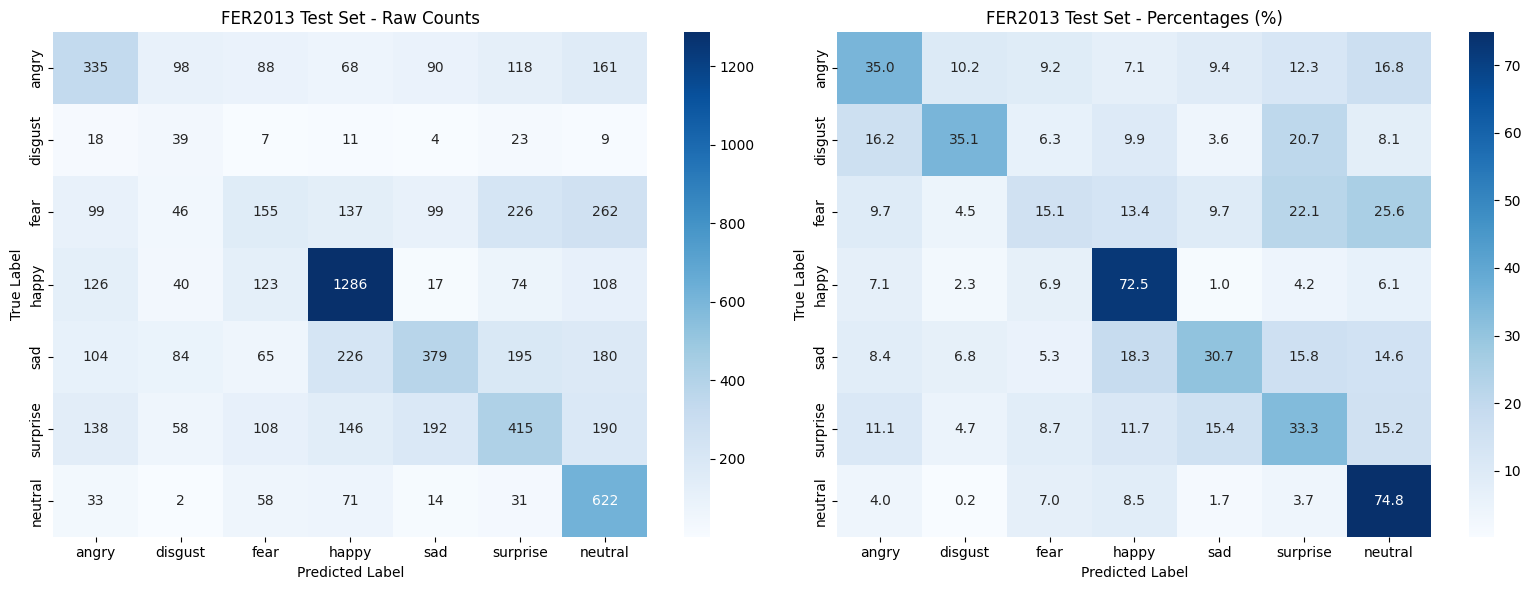


FER2013 - Detailed Metrics
              precision    recall  f1-score   support

       angry     0.3927    0.3497    0.3700       958
     disgust     0.1063    0.3514    0.1632       111
        fear     0.2566    0.1514    0.1904      1024
       happy     0.6612    0.7249    0.6916      1774
         sad     0.4767    0.3074    0.3738      1233
    surprise     0.3835    0.3328    0.3564      1247
     neutral     0.4060    0.7485    0.5264       831

    accuracy                         0.4501      7178
   macro avg     0.3833    0.4237    0.3817      7178
weighted avg     0.4496    0.4501    0.4370      7178


Per-Class Accuracy:
angry       :  34.97%
disgust     :  35.14%
fear        :  15.14%
happy       :  72.49%
sad         :  30.74%
surprise    :  33.28%
neutral     :  74.85%

Overall Accuracy: 45.01%


In [41]:
# Emotion labels
emotions = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

print("\n" + "="*60)
print("Generating Confusion Matrices and Metrics")
print("="*60)

# RAF-DB Test Set
print("\nEvaluating RAF-DB test set...")
raf_preds, raf_labels = get_predictions(model, test_raf_loader, device)
plot_confusion_matrix(raf_labels, raf_preds, emotions, 
                     'RAF-DB Test Set',
                     save_path='rafdb_confusion_matrix_final.png')
print_detailed_metrics(raf_labels, raf_preds, emotions, 'RAF-DB')

# FER2013 Test Set
print("\nEvaluating FER2013 test set...")
fer_preds, fer_labels = get_predictions(model, test_fer_loader, device)
plot_confusion_matrix(fer_labels, fer_preds, emotions, 
                     'FER2013 Test Set', 
                     save_path='fer2013_confusion_matrix_final.png')
print_detailed_metrics(fer_labels, fer_preds, emotions, 'FER2013')

In [42]:
# Emotion labels
emotions = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

print("\n" + "="*60)
print("Generating Confusion Matrices and Metrics")
print("="*60)

# RAF-DB Test Set
print("\nEvaluating RAF-DB test set...")
raf_preds, raf_labels = get_predictions(model, test_raf_loader, device)
print_detailed_metrics_with_uar_war(raf_labels, raf_preds, emotions, 'RAF-DB')

# FER2013 Test Set
print("\nEvaluating FER2013 test set...")
fer_preds, fer_labels = get_predictions(model, test_fer_loader, device)
print_detailed_metrics_with_uar_war(fer_labels, fer_preds, emotions, 'FER2013')


Generating Confusion Matrices and Metrics

Evaluating RAF-DB test set...


Getting predictions: 100%|█████████████████████████████████████████████████████████████| 96/96 [00:16<00:00,  5.84it/s]



RAF-DB - Detailed Metrics
              precision    recall  f1-score   support

       angry     0.6349    0.7407    0.6838       162
     disgust     0.4450    0.5813    0.5041       160
        fear     0.3917    0.6351    0.4845        74
       happy     0.9394    0.8895    0.9137      1185
         sad     0.8200    0.7103    0.7612       680
    surprise     0.7257    0.7803    0.7520       478
     neutral     0.8031    0.7933    0.7982       329

    accuracy                         0.7924      3068
   macro avg     0.6800    0.7329    0.6996      3068
weighted avg     0.8100    0.7924    0.7985      3068


------------------------------------------------------------
Per-Class Recall (%):
------------------------------------------------------------
angry       :  74.07%
disgust     :  58.13%
fear        :  63.51%
happy       :  88.95%
sad         :  71.03%
surprise    :  78.03%
neutral     :  79.33%

------------------------------------------------------------
Summary Metrics

Getting predictions: 100%|███████████████████████████████████████████████████████████| 225/225 [00:30<00:00,  7.44it/s]


FER2013 - Detailed Metrics
              precision    recall  f1-score   support

       angry     0.3927    0.3497    0.3700       958
     disgust     0.1063    0.3514    0.1632       111
        fear     0.2566    0.1514    0.1904      1024
       happy     0.6612    0.7249    0.6916      1774
         sad     0.4767    0.3074    0.3738      1233
    surprise     0.3835    0.3328    0.3564      1247
     neutral     0.4060    0.7485    0.5264       831

    accuracy                         0.4501      7178
   macro avg     0.3833    0.4237    0.3817      7178
weighted avg     0.4496    0.4501    0.4370      7178


------------------------------------------------------------
Per-Class Recall (%):
------------------------------------------------------------
angry       :  34.97%
disgust     :  35.14%
fear        :  15.14%
happy       :  72.49%
sad         :  30.74%
surprise    :  33.28%
neutral     :  74.85%

------------------------------------------------------------
Summary Metric

# 8. Grad-CAM on images to highlight significance of Action Units

In [11]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [14]:
data = {"activations": None, "gradients": None}

def save_activations(module, input, output):
    data["activations"] = output

def save_gradients(module, grad_input, grad_output):
    data["gradients"] = grad_output[0]

target_layer = model.layer4[-1]
target_layer.register_forward_hook(save_activations)
target_layer.register_full_backward_hook(save_gradients)

In [15]:
def compute_heatmap(model, img_tensor):

    model.zero_grad()
    

    output = model(img_tensor)
    _, prediction = output.max(1)
    

    output[0, prediction].backward()
    

    acts = data["activations"]
    grads = data["gradients"]
    

    weights = torch.mean(grads, dim=1, keepdim=True)

    cam = torch.sum(weights * acts, dim=-1)

    b, l = cam.shape
    side = int(l**0.5) 
    cam = cam.view(b, side, side)
    
    cam = torch.relu(cam)
    cam = cam.detach().cpu().squeeze().numpy()
    
    return cam, prediction.item()

In [16]:
def upsample_heatmap(heatmap, image):
    if isinstance(image, torch.Tensor):
        image = image.detach().cpu().squeeze()
        if image.dim() == 3:
            image = image.permute(1, 2, 0).numpy()
        else:
            image = image.numpy()

    if torch.is_tensor(heatmap):
        heatmap = torch.maximum(heatmap, torch.tensor(0.0))
        heatmap = heatmap.numpy()
    else:
        heatmap = np.maximum(heatmap, 0)

    m, M = heatmap.min(), heatmap.max()
    if M - m > 0:
        heatmap_norm = 255 * ((heatmap - m) / (M - m))
    else:
        heatmap_norm = np.zeros_like(heatmap)
        
    heatmap_norm = np.uint8(heatmap_norm)
    
    heatmap_resized = cv2.resize(heatmap_norm, (image.shape[1], image.shape[0]))
    
    heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    
    if image.max() <= 1.0:
        image = np.uint8(image * 255)
    
    image_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        
    combined_img = cv2.addWeighted(heatmap_color, 0.7, image_bgr, 0.3, 0)
    
    return cv2.cvtColor(combined_img, cv2.COLOR_BGR2RGB)

In [17]:
def display_images(combined_image, image):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(combined_image)
    axes[0].set_title("Heatmap")
    axes[0].axis('off')
    axes[1].imshow(image)
    axes[1].set_title("Original Image")
    axes[1].axis('off')
    plt.show()

In [18]:
DATA_DIR = "../../datasets/RAFDB/DATASET/train/"
OUTPUT_DIR = "./cam_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

categories = sorted(os.listdir(DATA_DIR))

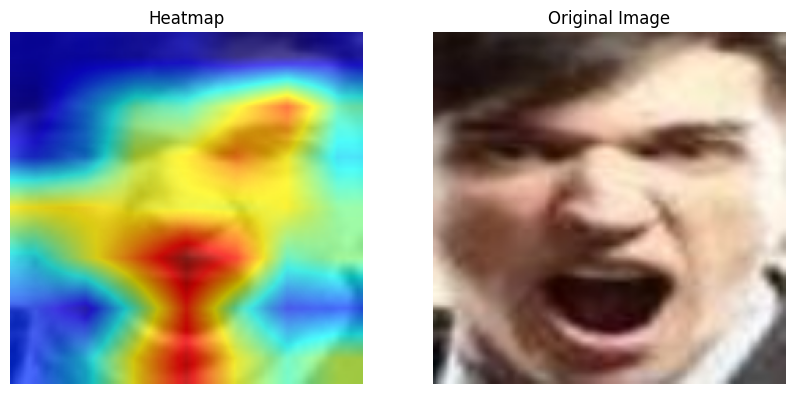

Processed angry, Predicted: angry


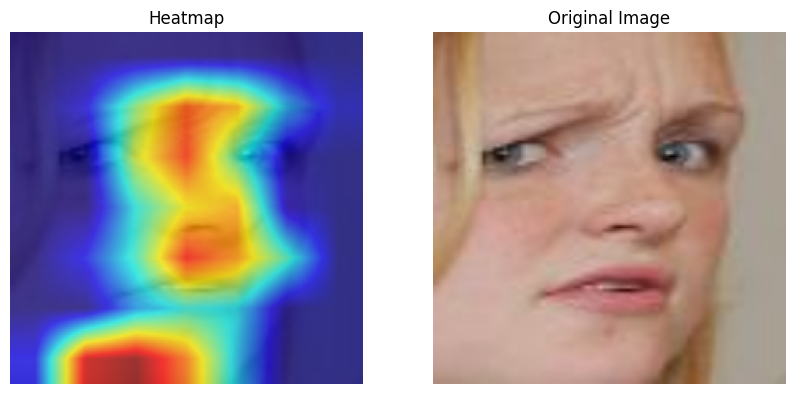

Processed disgust, Predicted: sad


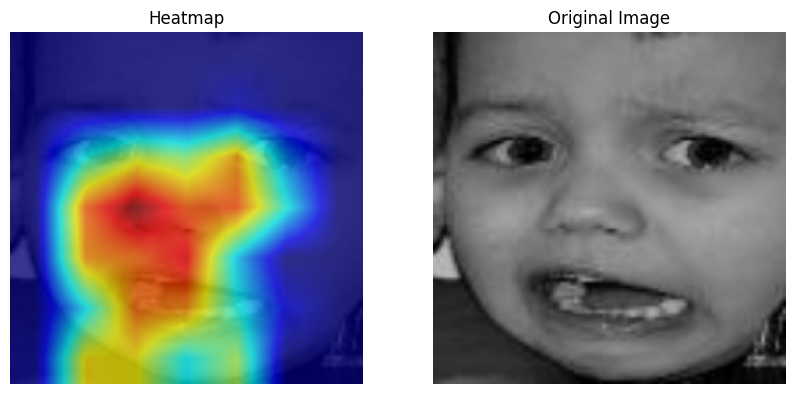

Processed fear, Predicted: fear


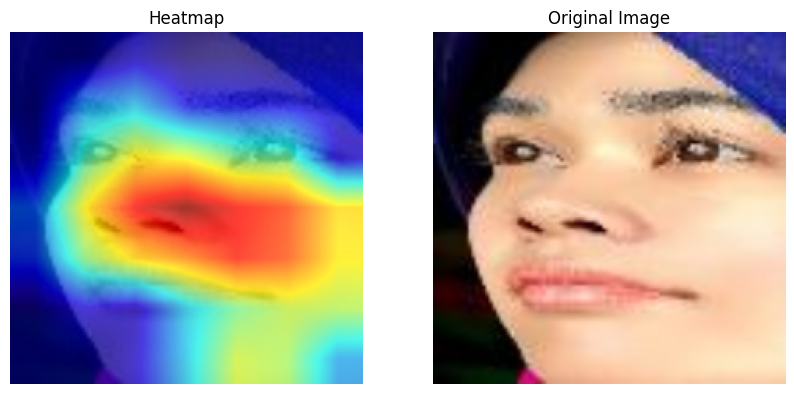

Processed happy, Predicted: happy


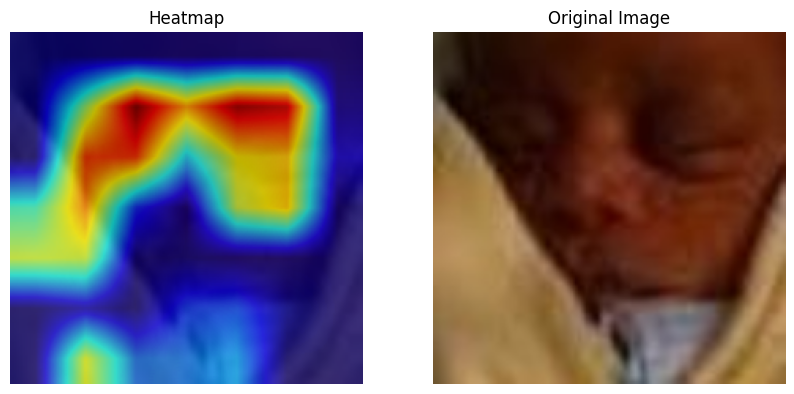

Processed neutral, Predicted: neutral


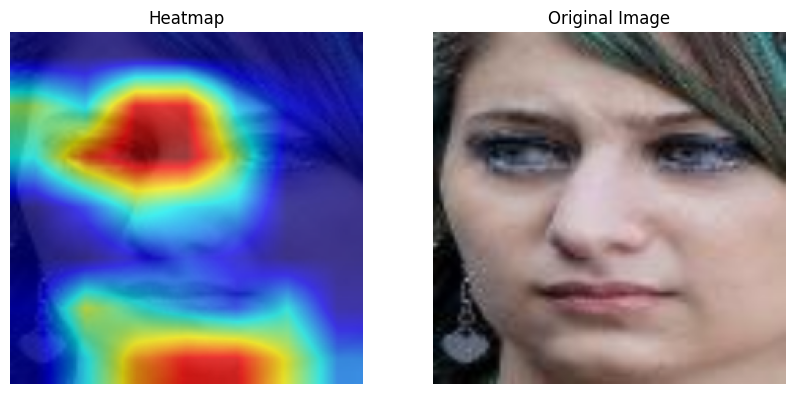

Processed sad, Predicted: sad


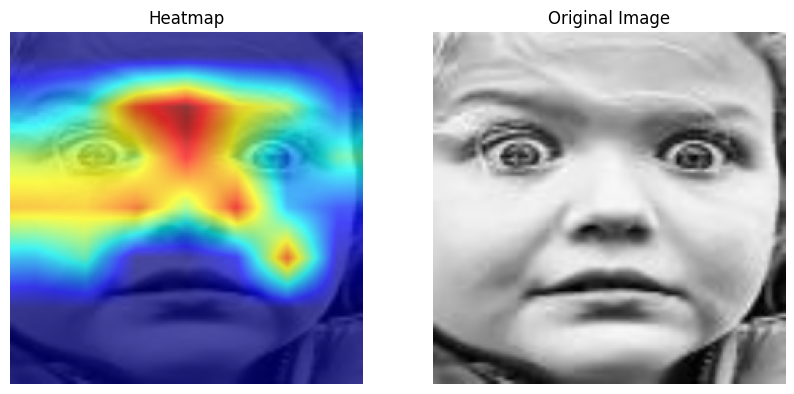

Processed surprise, Predicted: surprise


In [94]:
for category in categories:
    category_path = os.path.join(DATA_DIR, category)
    if not os.path.isdir(category_path):
        continue

    img_name = os.listdir(category_path)[0]
    img_path = os.path.join(category_path, img_name)

    img = cv2.imread(img_path)
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    rgb_img = cv2.resize(rgb_img, (224, 224))
    input_image_norm = np.float32(rgb_img) / 255
    input_tensor = transform(Image.fromarray(rgb_img)).unsqueeze(0).to(device)
    
    heatmap, pred_idx = compute_heatmap(model, input_tensor)
    predicted_label = categories[pred_idx]
    is_correct = (predicted_label == category)

    cam_image = upsample_heatmap(heatmap, rgb_img)
    display_images(cam_image, rgb_img)
    cam_image = cv2.cvtColor(cam_image, cv2.COLOR_RGB2BGR)
    save_path = os.path.join(OUTPUT_DIR, f"{category}_image_predicted_as_{predicted_label}.jpg")
    cv2.imwrite(save_path, cam_image)

    print(f"Processed {category}, Predicted: {predicted_label}")

In [19]:
def crop_to_square(img):
    h, w = img.shape[:2]
    
    if w > h:
        start_x = (w - h) // 2
        return img[:, start_x : start_x + h]
    elif h > w:
        start_y = (h - w) // 2
        return img[start_y : start_y + w, :]
    else:
        return img

In [20]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def get_face_crop(image):
    grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(grey, 1.3, 5)

    if len(faces) > 0:
        x, y, w, h = max(faces, key=lambda b: b[2] * b[3])

        side = max(w, h)
        center_x, center_y = x + w//2, y + h//2

        nx1 = max(0, center_x - side//2)
        ny1 = max(0, center_y - side//2)
        nx2 = min(image.shape[1], nx1 + side)
        ny2 = min(image.shape[0], ny1 + side)

        return image[ny1:ny2, nx1:nx2]

    return image

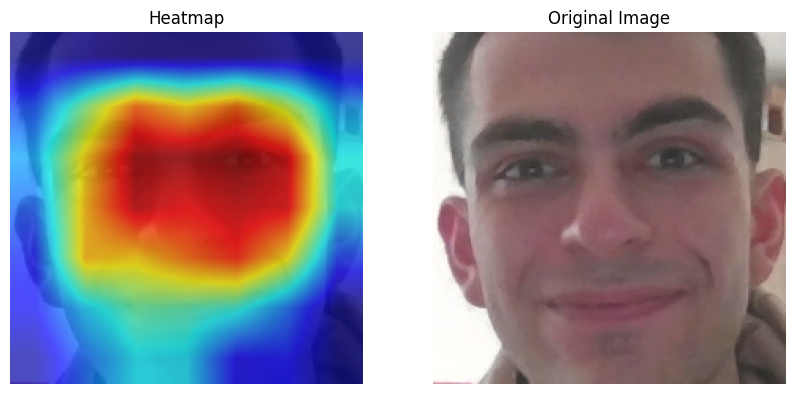

Predicted: happy


In [23]:
img = cv2.imread("me_lol.jpg")
img_face = get_face_crop(img)

rgb_img = cv2.cvtColor(img_face, cv2.COLOR_BGR2RGB)
rgb_img = crop_to_square(rgb_img)
rgb_img = cv2.resize(rgb_img, (224, 224))
input_image_norm = np.float32(rgb_img) / 255
input_tensor = transform(Image.fromarray(rgb_img)).unsqueeze(0).to(device)

heatmap, pred_idx = compute_heatmap(model, input_tensor)
predicted_label = categories[pred_idx]

cam_image = upsample_heatmap(heatmap, rgb_img)
display_images(cam_image, rgb_img)
cam_image = cv2.cvtColor(cam_image, cv2.COLOR_RGB2BGR)
cv2.imwrite(f"predicted_{predicted_label}.jpg", cam_image)
print(f"Predicted: {predicted_label}")

# t-SNE Clusters

In [14]:
def visualise_tsne(
    model: nn.Module,
    dataloader: DataLoader,
    class_names: Optional[list[str]] = None,
    n_pca_components: int = 50,
    tsne_perplexity: float = 30.0,
    tsne_max_iter: int = 1000,
    device: Optional[str] = None,
    save_path: Optional[str] = None,
    title: str = "t-SNE of SwinXception GAP Features",
) -> tuple[np.ndarray, np.ndarray]:
    """
    Extract post-GAP features from SwinXception and visualise with t-SNE.

    The extraction hook attaches after self.avgpool1d so features are
    768-d vectors — semantically rich, spatially summarised, and compact
    enough for reliable t-SNE embedding.

    Pipeline:  raw tokens (B, 49, 768)
                → LayerNorm → AdaptiveAvgPool1d → (B, 768)
                → PCA (50-d)  → t-SNE (2-d)  → scatter plot

    Args:
        model:             SwinXception instance (eval mode recommended).
        dataloader:        Yields (images, labels) batches.
        class_names:       Optional list mapping label indices to strings.
        n_pca_components:  PCA dimensionality before t-SNE (set 0 to skip).
        tsne_perplexity:   t-SNE perplexity; typically 5–50.
        tsne_max_iter:       t-SNE optimisation iterations.
        device:            'cuda', 'cpu', or auto-detected if None.
        save_path:         If given, saves the figure to this path.
        title:             Plot title.

    Returns:
        embeddings: (N, 2) t-SNE coordinates.
        labels:     (N,)   ground-truth class indices.
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model = model.to(device)
    model.eval()

    # Register a forward hook on avgpool1d to capture GAP output      
    gap_features: list[torch.Tensor] = []

    def _hook(module, input, output):
        # output shape: (B, 768, 1)  →  squeeze to (B, 768)
        gap_features.append(output.squeeze(-1).detach().cpu())

    hook_handle = model.avgpool1d.register_forward_hook(_hook)

    # Forward pass — no gradients needed                              
    all_labels: list[torch.Tensor] = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            _ = model(images)          # triggers the hook
            all_labels.append(labels.cpu())

    hook_handle.remove()

    features = torch.cat(gap_features, dim=0).numpy()   # (N, 768)
    labels   = torch.cat(all_labels,   dim=0).numpy()   # (N,)

    print(f"Extracted features: {features.shape}  |  samples: {len(labels)}")

    # ------------------------------------------------------------------ #
    # 3.  Optional PCA pre-reduction                                      #
    # ------------------------------------------------------------------ #
    if n_pca_components > 0 and features.shape[1] > n_pca_components:
        print(f"PCA: {features.shape[1]}-d → {n_pca_components}-d …")
        pca = PCA(n_components=n_pca_components, random_state=42)
        features = pca.fit_transform(features)
        explained = pca.explained_variance_ratio_.sum()
        print(f"  Explained variance retained: {explained:.1%}")

    # ------------------------------------------------------------------ #
    # 4.  t-SNE embedding                                                 #
    # ------------------------------------------------------------------ #
    print(f"t-SNE: {features.shape[1]}-d → 2-d  "
          f"(perplexity={tsne_perplexity}, n_iter={tsne_max_iter}) …")

    tsne = TSNE(
        n_components=2,
        perplexity=tsne_perplexity,
        max_iter=tsne_max_iter,
        random_state=42,
        init="pca",          # more stable than random init
        learning_rate="auto",
    )
    embeddings = tsne.fit_transform(features)   # (N, 2)
    print("Done.")

    # ------------------------------------------------------------------ #
    # 5.  Plot                                                            #
    # ------------------------------------------------------------------ #
    n_classes = len(np.unique(labels))
    cmap      = plt.get_cmap("tab10" if n_classes <= 10 else "tab20")
    colours   = [cmap(i / max(n_classes - 1, 1)) for i in range(n_classes)]

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_facecolor("#0f0f0f")
    fig.patch.set_facecolor("#0f0f0f")

    for cls_idx in range(n_classes):
        mask = labels == cls_idx
        ax.scatter(
            embeddings[mask, 0],
            embeddings[mask, 1],
            c=[colours[cls_idx]],
            s=12,
            alpha=0.75,
            linewidths=0,
            label=class_names[cls_idx] if class_names else str(cls_idx),
        )

    legend = ax.legend(
        loc="best",
        framealpha=0.2,
        edgecolor="white",
        labelcolor="white",
        fontsize=9,
    )
    ax.set_title(title, color="white", fontsize=13, pad=12)
    ax.tick_params(colors="grey")
    for spine in ax.spines.values():
        spine.set_edgecolor("#333333")

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()
    return embeddings, labels

Extracted features: (2455, 768)  |  samples: 2455
PCA: 768-d → 50-d …
  Explained variance retained: 99.4%
t-SNE: 50-d → 2-d  (perplexity=30.0, n_iter=1000) …
Done.
Saved to tsne-SMOTE.png


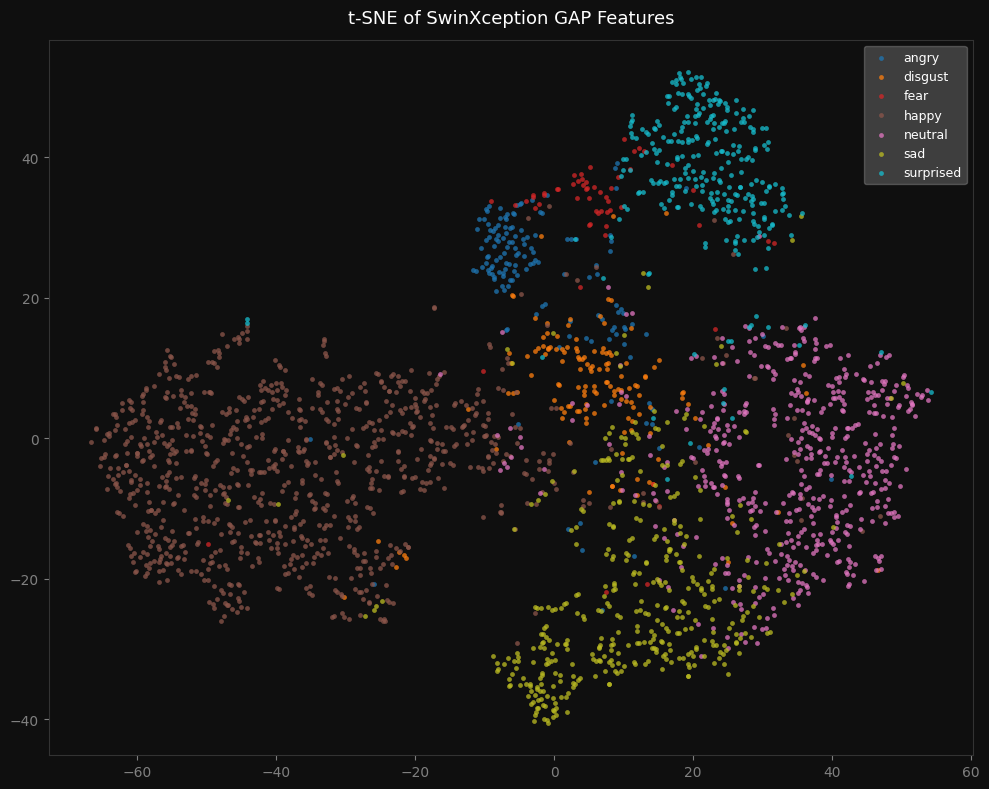

In [20]:
embeddings, labels = visualise_tsne(
    model       = model,
    dataloader  = val_loader,
    class_names = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprised"],
    save_path   = "tsne.png",
)